# Model Training v7

In [27]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append('..')
from src.features import FeatureOptions, load_feature_tables
from src.sanity_check import run_all as sanity_check

In [28]:
# Reproducibility & Config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Clinical gold standard: sustained vowel 'A' at normal pitch.
# Isolate to a single token first to prove multifractal features work
# before integrating other vowels/tokens.
SELECTED_TOKEN = 'a_n'
MIN_SAMPLES_PER_CLASS = 50
MAX_SAMPLES_PER_CLASS = 500

# Downsample healthy to match total pathological count (no upsampling/duplication).
# Tree models also handle residual imbalance via class_weight='balanced'.
BALANCE_HEALTHY = True

# Data quality guards
# Keep overlap filter OFF by default: it removes a large portion of pathological signal.
EXCLUDE_OVERLAP_SPEAKERS = False
EXCLUDE_MIXED_BINARY_SPEAKERS = True

N_SPLITS = 5
THRESHOLD_GRID = np.linspace(0.35, 0.65, 11)

# Optimize for what you care about most
BINARY_THRESHOLD_OBJECTIVE = 'accuracy'  # 'accuracy' | 'balanced_accuracy'

TARGET_SOURCE_COL_PREFERENCE = 'pathology_de'
USE_GROUPED_TARGET = True
KEEP_UNMAPPED_LABELS = False
UNMAPPED_LABEL = 'Other'

DISEASE_GROUP_MAP = {
    'Morbus Parkinson': 'Neurological',
    'Rekurrensparese': 'Neurological',
    'Spasmodische Dysphonie': 'Neurological',
    'Phonationsknötchen': 'Structural',
    'Stimmlippenpolyp': 'Structural',
    # 'Reinke Ödem': 'Structural',
    'Laryngitis': 'Structural',
    # 'Hypotone Dysphonie': 'Functional',
    # 'Hyperfunktionelle Dysphonie': 'Functional',
    # 'Psychogene Dysphonie': 'Functional',
    # 'Funktionelle Dysphonie': 'Functional',
    'Phonationsknötchen': 'Structural',
    # 'Reinke Ödem': 'Structural',
}

opts = FeatureOptions(
    prefix=Path('..'),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    balance_healthy=BALANCE_HEALTHY,
    selected_token=SELECTED_TOKEN,
    num_workers=None,
    mfdfa_q_step=0.5,
    mfdfa_num_scales=40,
    target_sample_rate=50000
)
opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, num_workers=None, max_samples_per_class=500, balance_healthy=True, normalize_audio=True, target_sample_rate=50000, selected_token='a_n', mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=0.5, mfdfa_num_scales=40)

In [29]:
# Load Features (Sample Level) with config-safety check
build_cfg_path = Path('..') / 'data' / 'processed' / 'features' / 'feature_build_config.json'
desired_cfg = {
    'max_samples_per_class': MAX_SAMPLES_PER_CLASS,
    'balance_healthy': BALANCE_HEALTHY,
    'target_sample_rate': opts.target_sample_rate,
    'selected_token': SELECTED_TOKEN,
}

force_rebuild = False
if build_cfg_path.exists():
    saved_cfg = json.loads(build_cfg_path.read_text(encoding='utf-8'))
    mismatches = {
        k: (saved_cfg.get(k), v)
        for k, v in desired_cfg.items()
        if saved_cfg.get(k) != v
    }
    if mismatches:
        force_rebuild = True
        print('Config mismatch vs cached features -> forcing rebuild:')
        for k, (old_v, new_v) in mismatches.items():
            print(f'  {k}: cached={old_v} -> desired={new_v}')

if force_rebuild:
    feature_dir = Path('..') / 'data' / 'processed' / 'features'
    for p in [
        feature_dir / 'sample_core.csv',
        feature_dir / 'acoustic_features.csv',
        feature_dir / 'multifractal_features.csv',
        feature_dir / 'opensmile_features.csv',
        feature_dir / 'sample_splits.csv',
        feature_dir / 'feature_summary.json',
        feature_dir / 'feature_build_config.json',
    ]:
        if p.exists():
            p.unlink()
    print('Deleted stale cached feature artifacts. Rebuilding now...')

tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

# Deduplicate each table on sample_key before merging to prevent
# cartesian explosion if upstream pipeline produces duplicate keys.
core_df = tables['core'].drop_duplicates(subset=['sample_key']).copy()
acoustic_df = tables['acoustic'].drop_duplicates(subset=['sample_key']).copy()
multifractal_df = tables['multifractal'].drop_duplicates(subset=['sample_key']).copy()
opensmile_df = tables.get('opensmile', pd.DataFrame()).drop_duplicates(subset=['sample_key']).copy() if 'opensmile' in tables and not tables.get('opensmile', pd.DataFrame()).empty else pd.DataFrame()
splits_df = tables.get('splits', pd.DataFrame()).drop_duplicates(subset=['sample_key']).copy() if 'splits' in tables and not tables.get('splits', pd.DataFrame()).empty else pd.DataFrame()

# df = core_df.merge(acoustic_df, on='sample_key', how='left')
df = core_df # Skip acoustic features for now to isolate multifractal contribution
df = df.merge(multifractal_df, on='sample_key', how='left')
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on='sample_key', how='left')
if not splits_df.empty:
    df = df.merge(splits_df, on='sample_key', how='left')

if 'feature_status' in df.columns:
    df = df[df['feature_status'].isin(['ok', 'partial_failure'])].copy()
if 'acoustic_status' in df.columns:
    df = df[df['acoustic_status'] == 'ok'].copy()
if 'mf_status' in df.columns:
    df = df[df['mf_status'] == 'ok'].copy()
if 'opensmile_status' in df.columns:
    df = df[df['opensmile_status'] == 'ok'].copy()

# Compute age at recording from manifest birth_date / recording_date
# That is, find the age at record time
manifest_path = Path('..') / 'data' / 'processed' / 'manifests' / 'dataset_manifest.csv'
manifest_dates = pd.read_csv(manifest_path, usecols=['sample_key', 'birth_date', 'recording_date'])
manifest_dates = manifest_dates.drop_duplicates(subset=['sample_key'])
df = df.merge(manifest_dates, on='sample_key', how='left')
bd = pd.to_datetime(df['birth_date'], errors='coerce')
rd = pd.to_datetime(df['recording_date'], errors='coerce')
df['age'] = ((rd - bd).dt.days / 365.25).round(1)
df.drop(columns=['birth_date', 'recording_date'], inplace=True)
print(f"Age: mean={df['age'].mean():.1f}  min={df['age'].min():.1f}  max={df['age'].max():.1f}  missing={df['age'].isna().sum()}")

print('Merged sample-level shape:', df.shape)
print('Unique speakers:', df['speaker_id'].nunique())

Config mismatch vs cached features -> forcing rebuild:
  target_sample_rate: cached=22050 -> desired=50000
Deleted stale cached feature artifacts. Rebuilding now...


Extracting features:   0%|          | 0/1656 [00:00<?, ?sample/s]

Age: mean=41.2  min=9.2  max=94.7  missing=0
Merged sample-level shape: (1656, 127)
Unique speakers: 1355


In [30]:
# Build Targets
raw_target = df[TARGET_SOURCE_COL_PREFERENCE].astype(str).str.strip()
if USE_GROUPED_TARGET:
    mapped_target = raw_target.map(DISEASE_GROUP_MAP)
    # Drop pathological samples whose raw pathology is NOT in DISEASE_GROUP_MAP
    # (healthy rows are kept regardless)
    unmapped_mask = mapped_target.isna() & ~df['is_healthy'].astype(bool)
    if unmapped_mask.any():
        dropped_labels = raw_target[unmapped_mask].value_counts().to_dict()
        print(f'Dropping {unmapped_mask.sum()} samples with unmapped pathologies: {dropped_labels}')
        df = df[~unmapped_mask].copy()
        raw_target = raw_target[~unmapped_mask]
        mapped_target = mapped_target[~unmapped_mask]
    # Preserve 'healthy' label for healthy rows (not in DISEASE_GROUP_MAP)
    mapped_target = mapped_target.where(~df['is_healthy'].astype(bool), other=mapped_target)
    mapped_target.loc[df['is_healthy'].astype(bool)] = 'healthy'
    mapped_target = mapped_target.fillna(raw_target if KEEP_UNMAPPED_LABELS else UNMAPPED_LABEL)
    df['target_label'] = mapped_target.astype(str)
else:
    df['target_label'] = raw_target

target_col = 'target_label'

# Optional quality guard 1: remove overlap speakers that appear in multiple pathologies
if EXCLUDE_OVERLAP_SPEAKERS:
    overlap_cols = [c for c in ['is_overlap_speaker', 'is_overlap_speaker_id'] if c in df.columns]
    if overlap_cols:
        overlap_mask = pd.Series(False, index=df.index)
        for c in overlap_cols:
            overlap_mask = overlap_mask | df[c].astype(str).str.lower().eq('true')
        removed = int(overlap_mask.sum())
        if removed > 0:
            print(f'Removing overlap-speaker rows: {removed}')
            df = df.loc[~overlap_mask].copy()

# quality guard 2: remove speakers with mixed binary labels (healthy + pathological)
if EXCLUDE_MIXED_BINARY_SPEAKERS and 'speaker_id' in df.columns and 'is_healthy' in df.columns:
    grp = df.groupby(df['speaker_id'].astype(str))['is_healthy'].nunique()
    bad_speakers = set(grp[grp > 1].index.tolist())
    if bad_speakers:
        removed = int(df['speaker_id'].astype(str).isin(bad_speakers).sum())
        print(f'Removing mixed-label speaker rows: {removed} from {len(bad_speakers)} speakers')
        df = df.loc[~df['speaker_id'].astype(str).isin(bad_speakers)].copy()

small_classes = df[target_col].value_counts()[df[target_col].value_counts() < MIN_SAMPLES_PER_CLASS].index.tolist()
if small_classes:
    print(f'Dropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {small_classes}')
    df = df[~df[target_col].isin(small_classes)].copy()

# Re-balance healthy to match total pathological count after any drops
if BALANCE_HEALTHY:
    n_patho = int((~df['is_healthy'].astype(bool)).sum())
    healthy_mask = df['is_healthy'].astype(bool)
    n_healthy = int(healthy_mask.sum())
    if n_healthy > n_patho:
        drop_n = n_healthy - n_patho
        drop_idx = df[healthy_mask].sample(n=drop_n, random_state=RANDOM_SEED).index
        df = df.drop(drop_idx).copy()
        print(f'Re-balanced healthy: {n_healthy} -> {n_patho} (dropped {drop_n})')

display(df[target_col].value_counts().to_frame('sample_count'))

Dropping 489 samples with unmapped pathologies: {'Hyperfunktionelle Dysphonie': 213, 'Funktionelle Dysphonie': 112, 'Psychogene Dysphonie': 91, 'Reinke Ödem': 68, 'Hypotone Dysphonie': 5}
Removing mixed-label speaker rows: 4 from 2 speakers
Re-balanced healthy: 685 -> 478 (dropped 207)


,sample_count
target_label,
healthy,478
Neurological,277
Structural,201


In [31]:
# Prep Training Matrices
meta_cols = {
    'sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id', 'wav_path',
    'feature_status', 'feature_error', 'acoustic_status', 'acoustic_error',
    'mf_status', 'mf_error', 'opensmile_status', 'opensmile_error',
    'split', 'split_seed', 'pathology_de', 'pathology_en', target_col, 'is_healthy',
    'is_overlap_speaker', 'is_overlap_speaker_id',
}

numeric_cols = [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]

# ── Drop experimental feature groups ──
import re
_drop_patterns = [
    re.compile(r'mfcc', re.IGNORECASE),                      # All MFCC columns
    re.compile(r'F[123](frequency|bandwidth|amplitudeLogRelF0)', re.IGNORECASE),  # F1/F2/F3 freq & bw
    re.compile(r'lsp', re.IGNORECASE),                        # LSP (Line Spectral Pairs)
]
_before = len(numeric_cols)
numeric_cols = [c for c in numeric_cols if not any(p.search(c) for p in _drop_patterns)]
print(f'Dropped {_before - len(numeric_cols)} features (MFCC, F1/F2/F3, LSP). Remaining: {len(numeric_cols)}')

# Drop highly collinear features (|r| > threshold). Keep the first in each correlated pair.
COLLINEARITY_THRESHOLD = 0.85
corr_matrix = df[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
collinear_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > COLLINEARITY_THRESHOLD)]
if collinear_to_drop:
    print(f'Dropping {len(collinear_to_drop)} collinear features (|r| > {COLLINEARITY_THRESHOLD}):')
    print(f'  {collinear_to_drop}')
    numeric_cols = [c for c in numeric_cols if c not in collinear_to_drop]

categorical_cols = []
if 'sex' in df.columns:
    categorical_cols.append('sex')

X = df[numeric_cols + categorical_cols].copy()
# Binary classification: 1=Healthy, 0=Pathological
y_bin = df['is_healthy'].astype(int).copy()
y_multi = df[target_col].astype(str).copy()
groups = df['speaker_id'].astype(str).copy()
tokens = df['token'].astype(str).copy() if 'token' in df.columns else pd.Series(['__missing__'] * len(df), index=df.index)

print('Total tokens/samples:', len(df))
print('Features per sample:', len(numeric_cols))
print('Categorical columns:', categorical_cols)
print('Unique tokens:', tokens.nunique())

Dropped 34 features (MFCC, F1/F2/F3, LSP). Remaining: 72
Dropping 21 collinear features (|r| > 0.85):
  ['audio_duration_seconds', 'mf_hq_min', 'mf_hq_max', 'mf_tau_mean', 'mf_tau_std', 'mf_alpha_mean', 'mf_alpha_std', 'mf_spectrum_width', 'mf_spectrum_peak_alpha', 'os_F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'os_F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'os_F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'os_F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'os_loudness_sma3_percentile20.0', 'os_loudness_sma3_percentile50.0', 'os_loudness_sma3_percentile80.0', 'os_spectralFluxV_sma3nz_amean', 'os_spectralFluxV_sma3nz_stddevNorm', 'os_hammarbergIndexUV_sma3nz_amean', 'os_spectralFluxUV_sma3nz_amean', 'os_MeanVoicedSegmentLengthSec']
Total tokens/samples: 956
Features per sample: 51
Categorical columns: ['sex']
Unique tokens: 1


In [32]:
# Sanity Check — display diagnostics before training
sanity_check(df, tables, opts, numeric_cols, categorical_cols, target_col=target_col)


────────────────────────────────────────────────────────────
  Build Configuration
────────────────────────────────────────────────────────────
  selected_token                  a_n
  target_sample_rate              50000
  max_samples_per_class           500
  balance_healthy                 True
  normalize_audio                 True
  mfdfa_order                     1
  mfdfa_q_range                   [-5.0, 5.0] step 0.5
  mfdfa_num_scales                40
  random_seed                     42

────────────────────────────────────────────────────────────
  Data Overview
────────────────────────────────────────────────────────────
Total samples (rows):  956
Total columns:         128
Unique speakers:       820
Unique tokens:         1  →  ['a_n']
Sex distribution:      {'w': 572, 'm': 384}

────────────────────────────────────────────────────────────
  Class Distribution
────────────────────────────────────────────────────────────
  healthy                         478 (50.0%)
  Neu

In [33]:
# Preprocessing Pipeline
TREE_MODELS = (RandomForestClassifier, XGBClassifier, LGBMClassifier)

# Tree-friendly: pass numerics through as-is (NaN preserved), one-hot categoricals
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
    ] if categorical_cols else [
        ('num', 'passthrough', numeric_cols),
    ],
    remainder='drop',
).set_output(transform='pandas')

# Linear-model preprocessor: imputation + scaling required
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value=0.0, add_indicator=True)),
            ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
            ('variance', VarianceThreshold(threshold=0.0)),
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
    ] if categorical_cols else [
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value=0.0, add_indicator=True)),
            ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
            ('variance', VarianceThreshold(threshold=0.0)),
        ]), numeric_cols),
    ],
    remainder='drop',
).set_output(transform='pandas')

def make_pipe(model):
    """Build pipeline: auto-selects tree vs linear preprocessor, no feature selection."""
    prep = tree_preprocessor if isinstance(model, TREE_MODELS) else linear_preprocessor
    return Pipeline(steps=[
        ('prep', prep),
        ('model', model),
    ])

In [34]:
def _make_sample_weights(y_enc):
    classes = np.unique(y_enc)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_enc)
    weight_map = {cls: w for cls, w in zip(classes, weights)}
    return np.array([weight_map[v] for v in y_enc], dtype=float)


def evaluate_binary_sample_cv(model, X, y, groups, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    fold_rows = []
    all_y_true, all_y_pred = [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        pipe = make_pipe(clone(model))
        pipe.fit(X_tr, y_tr)
        
        # Fast threshold tuning on train probas (objective configurable)
        p_tr = pipe.predict_proba(X_tr)[:, 1]
        best_thr, best_score = 0.5, -1.0
        for thr in THRESHOLD_GRID:
            pred_tr = (p_tr >= thr).astype(int)
            if BINARY_THRESHOLD_OBJECTIVE == 'accuracy':
                score = accuracy_score(y_tr, pred_tr)
            else:
                score = balanced_accuracy_score(y_tr, pred_tr)
            if score > best_score:
                best_score = score
                best_thr = float(thr)

        p_te = pipe.predict_proba(X_te)[:, 1]
        pred_te = (p_te >= best_thr).astype(int)
        all_y_true.extend(y_te.tolist())
        all_y_pred.extend(pred_te.tolist())

        fold_rows.append({
            'fold': fold,
            'threshold': best_thr,
            'accuracy': accuracy_score(y_te, pred_te),
            'balanced_accuracy': balanced_accuracy_score(y_te, pred_te),
            'f1_macro': f1_score(y_te, pred_te, average='macro', zero_division=0),
        })
        
    fold_df = pd.DataFrame(fold_rows)
    return fold_df, {
        'accuracy_mean': fold_df['accuracy'].mean(),
        'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
        'f1_macro_mean': fold_df['f1_macro'].mean(),
    }, np.array(all_y_true), np.array(all_y_pred)


def evaluate_multiclass_cv(model, X, y, groups, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_rows = []
    all_y_true, all_y_pred = [], []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        le = LabelEncoder()
        y_tr_enc = le.fit_transform(y_tr.astype(str))
        y_te_enc = le.transform(y_te.astype(str))
        sw = _make_sample_weights(y_tr_enc)

        pipe = make_pipe(clone(model))
        pipe.fit(X_tr, y_tr_enc, model__sample_weight=sw)
        pred_enc = pipe.predict(X_te)
        all_y_true.extend(le.inverse_transform(y_te_enc))
        all_y_pred.extend(le.inverse_transform(pred_enc))

        fold_rows.append({
            'fold': fold,
            'accuracy': accuracy_score(y_te_enc, pred_enc),
            'balanced_accuracy': balanced_accuracy_score(y_te_enc, pred_enc),
            'f1_macro': f1_score(y_te_enc, pred_enc, average='macro', zero_division=0),
        })

    fold_df = pd.DataFrame(fold_rows)
    return fold_df, {
        'accuracy_mean': fold_df['accuracy'].mean(),
        'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
        'f1_macro_mean': fold_df['f1_macro'].mean(),
    }, np.array(all_y_true), np.array(all_y_pred)

In [35]:
# Binary Classification Run
binary_models = {
    'LogReg': LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=2,
        class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=800, learning_rate=0.03, num_leaves=63,
        min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=700, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=1.0, reg_lambda=2.0,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss'
    ),
}

# Token-level metrics (no K sweep — all features used natively)
bin_rows = []
bin_cm_data = {}  # model_name -> (y_true, y_pred)
for model_name, model in binary_models.items():
    fold_df, summ, yt, yp = evaluate_binary_sample_cv(model, X, y_bin, groups, n_splits=N_SPLITS)
    bin_rows.append({'model': model_name, **summ})
    bin_cm_data[model_name] = (yt, yp)

bin_results = pd.DataFrame(bin_rows).sort_values(
    by=['accuracy_mean', 'balanced_accuracy_mean'], ascending=False
).reset_index(drop=True)
print('Binary metrics (sample-level)')
display(bin_results)

Binary metrics (sample-level)


,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,XGBoost,0.884959,0.885022,0.884863
1,LightGBM,0.880781,0.880811,0.880699
2,LogReg,0.865140,0.865175,0.864654
3,RandomForest,0.854663,0.854649,0.854378


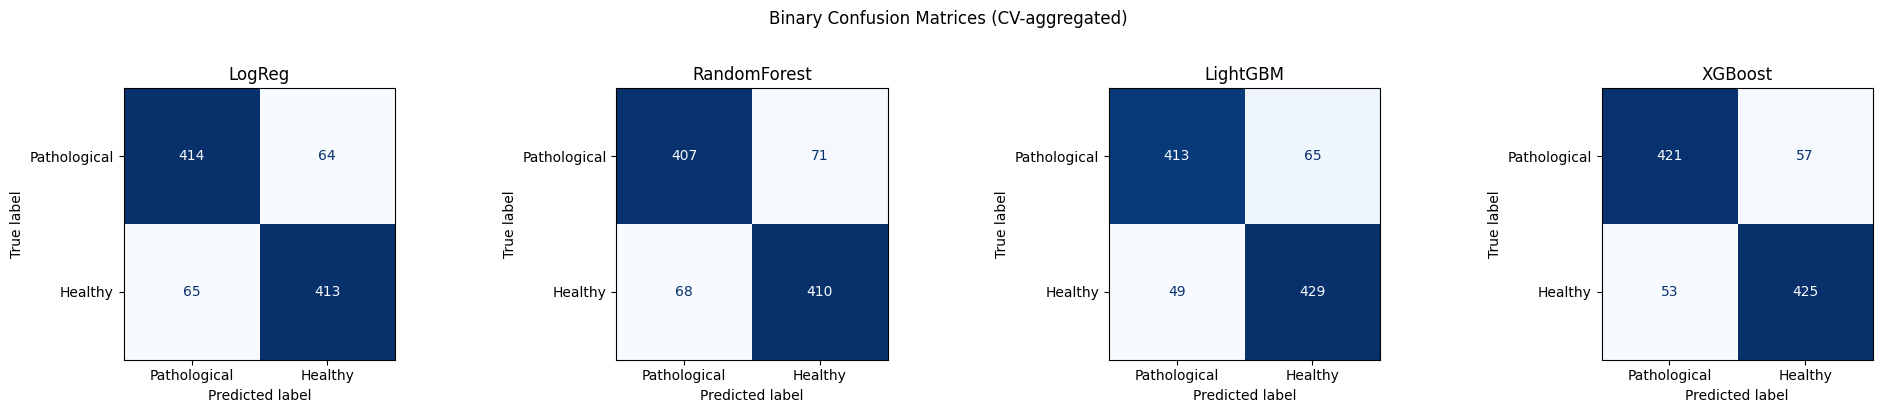

In [36]:
# Binary Confusion Matrices (aggregated across CV folds)
fig, axes = plt.subplots(1, len(bin_cm_data), figsize=(5 * len(bin_cm_data), 4))
if len(bin_cm_data) == 1:
    axes = [axes]
for ax, (model_name, (yt, yp)) in zip(axes, bin_cm_data.items()):
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Pathological', 'Healthy']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(model_name)
fig.suptitle('Binary Confusion Matrices (CV-aggregated)', y=1.02)
fig.tight_layout()
plt.show()

In [37]:
# Multi-Class Run (Pathological Only)
idx_patho = y_bin == 0
X_patho, y_patho, g_patho = X[idx_patho], y_multi[idx_patho], groups[idx_patho]

multi_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=1.0, reg_lambda=2.0,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss'
    ),
}

# Run baseline models (no K sweep — all features used natively)
multi_rows = []
multi_cm_data = {}  # model_name -> (y_true, y_pred)
for model_name, model in multi_models.items():
    fold_df, summ, yt, yp = evaluate_multiclass_cv(model, X_patho, y_patho, g_patho, n_splits=N_SPLITS)
    multi_rows.append({'model': model_name, **summ})
    multi_cm_data[model_name] = (yt, yp)

multi_results = pd.DataFrame(multi_rows).sort_values(
    by=['accuracy_mean', 'balanced_accuracy_mean'], ascending=False
).reset_index(drop=True)
print('Multi-class metrics (sample-level)')
display(multi_results)

Multi-class metrics (sample-level)


,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,RandomForest,0.654890,0.636455,0.637466
1,LightGBM,0.654649,0.649977,0.648200
2,XGBoost,0.650592,0.643711,0.642804


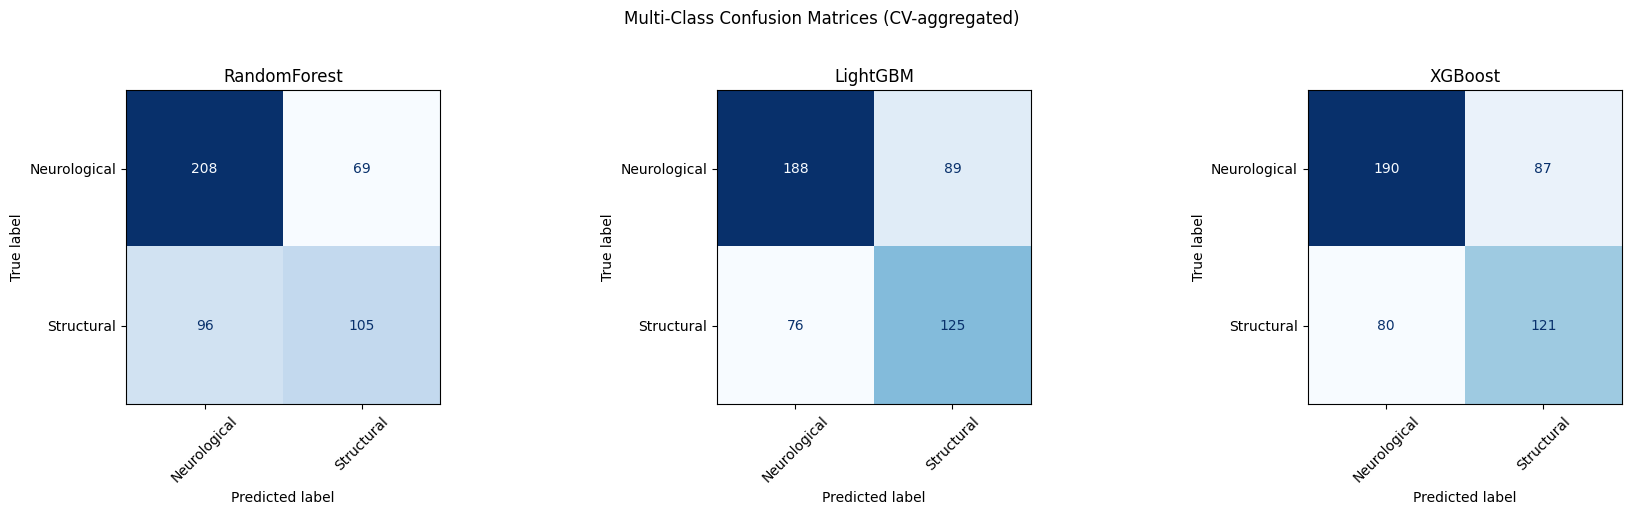

In [38]:
# Multi-Class Confusion Matrices (aggregated across CV folds)
labels = sorted(y_patho.unique())
fig, axes = plt.subplots(1, len(multi_cm_data), figsize=(6 * len(multi_cm_data), 5))
if len(multi_cm_data) == 1:
    axes = [axes]
for ax, (model_name, (yt, yp)) in zip(axes, multi_cm_data.items()):
    cm = confusion_matrix(yt, yp, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(model_name)
fig.suptitle('Multi-Class Confusion Matrices (CV-aggregated)', y=1.02)
fig.tight_layout()
plt.show()

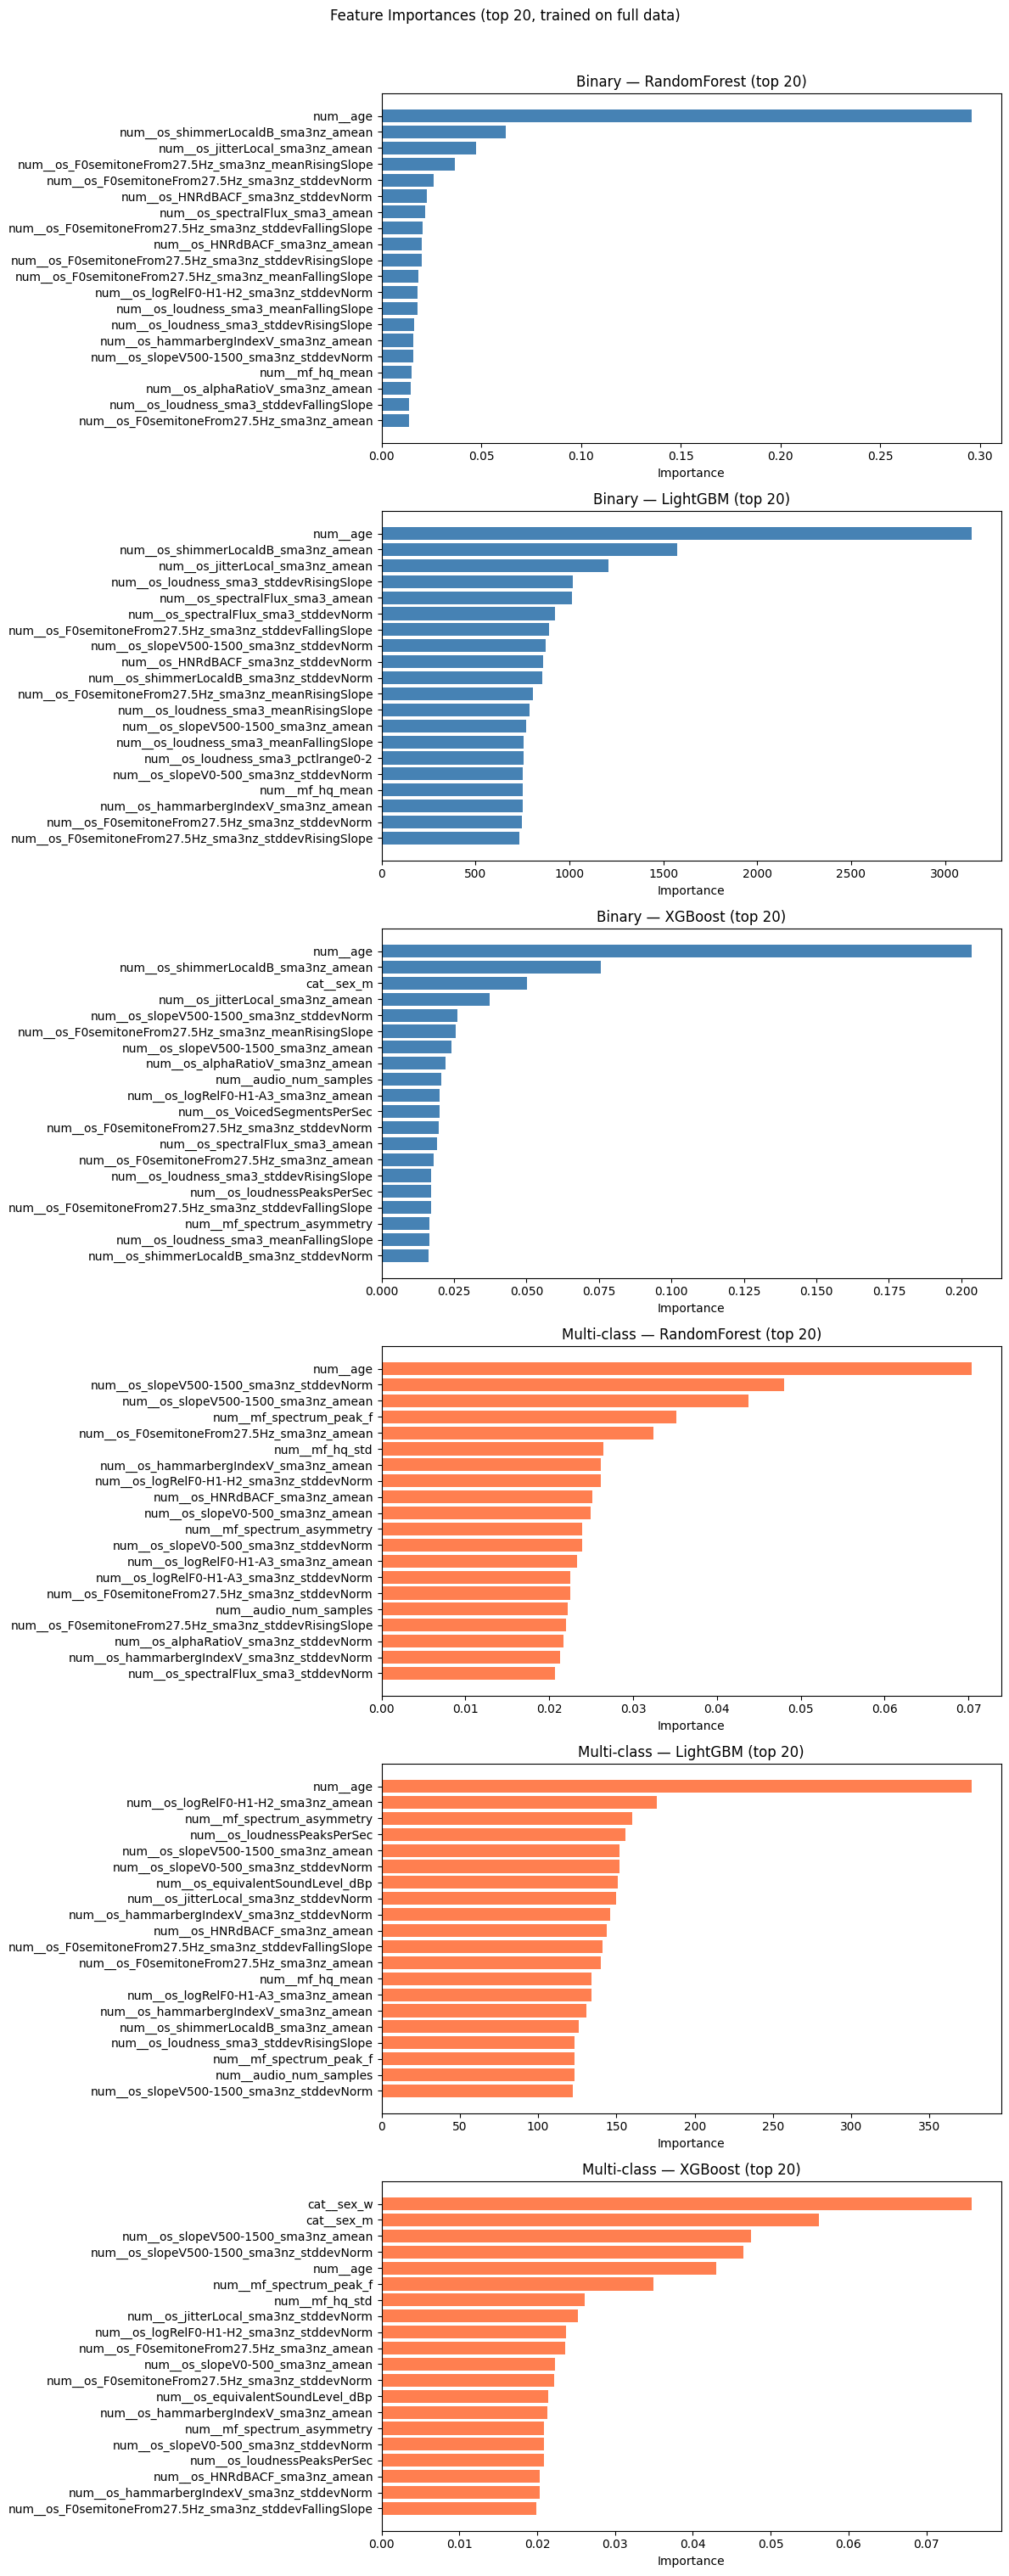

In [39]:
# Feature Importances (retrain on full data for visualization)
IMPORTANCE_MODELS = {
    'binary': {name: m for name, m in binary_models.items() if isinstance(m, TREE_MODELS)},
    'multi': {name: m for name, m in multi_models.items() if isinstance(m, TREE_MODELS)},
}

def _get_feature_names(pipe):
    """Extract feature names from a fitted pipeline."""
    prep = pipe.named_steps['prep']
    return prep.get_feature_names_out()

fig, axes = plt.subplots(
    len(IMPORTANCE_MODELS['binary']) + len(IMPORTANCE_MODELS['multi']), 1,
    figsize=(12, 5 * (len(IMPORTANCE_MODELS['binary']) + len(IMPORTANCE_MODELS['multi']))),
)
axes = np.atleast_1d(axes)
ax_idx = 0

# Binary importances
for model_name, model in IMPORTANCE_MODELS['binary'].items():
    pipe = make_pipe(clone(model))
    pipe.fit(X, y_bin)
    importances = pipe.named_steps['model'].feature_importances_
    feat_names = _get_feature_names(pipe)
    top_k = min(20, len(feat_names))
    sorted_idx = np.argsort(importances)[-top_k:]
    axes[ax_idx].barh(range(top_k), importances[sorted_idx], color='steelblue')
    axes[ax_idx].set_yticks(range(top_k))
    axes[ax_idx].set_yticklabels([feat_names[i] for i in sorted_idx])
    axes[ax_idx].set_title(f'Binary — {model_name} (top {top_k})')
    axes[ax_idx].set_xlabel('Importance')
    ax_idx += 1

# Multi-class importances (pathological only)
le_full = LabelEncoder()
y_patho_enc = le_full.fit_transform(y_patho.astype(str))
sw_full = _make_sample_weights(y_patho_enc)

for model_name, model in IMPORTANCE_MODELS['multi'].items():
    pipe = make_pipe(clone(model))
    pipe.fit(X_patho, y_patho_enc, model__sample_weight=sw_full)
    importances = pipe.named_steps['model'].feature_importances_
    feat_names = _get_feature_names(pipe)
    top_k = min(20, len(feat_names))
    sorted_idx = np.argsort(importances)[-top_k:]
    axes[ax_idx].barh(range(top_k), importances[sorted_idx], color='coral')
    axes[ax_idx].set_yticks(range(top_k))
    axes[ax_idx].set_yticklabels([feat_names[i] for i in sorted_idx])
    axes[ax_idx].set_title(f'Multi-class — {model_name} (top {top_k})')
    axes[ax_idx].set_xlabel('Importance')
    ax_idx += 1

fig.suptitle('Feature Importances (top 20, trained on full data)', y=1.01)
fig.tight_layout()
plt.show()